<a href="https://colab.research.google.com/github/Sophiagazula/agentic-ai-projects/blob/main/Sample_Demand_Forecasting_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('forecasting_dataset.csv')
df.head()

,date,warehouse_id,region,sku_id,demand_qty,promo_flag
0,2025-01-01,W1,East,SKU1,17,0
1,2025-01-02,W1,East,SKU1,18,0
2,2025-01-03,W1,East,SKU1,30,0
3,2025-01-04,W1,East,SKU1,25,0
4,2025-01-05,W1,East,SKU1,25,0


In [7]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8688 entries, 0 to 8687
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          8688 non-null   datetime64[ns]
 1   warehouse_id  8688 non-null   object        
 2   region        8688 non-null   object        
 3   sku_id        8688 non-null   object        
 4   demand_qty    8688 non-null   int64         
 5   promo_flag    8688 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 407.4+ KB


In [14]:
#Aggregatedemand

daily = df.groupby(['date','sku_id'])['demand_qty'].sum().reset_index()
daily.head()

,date,sku_id,demand_qty
0,2025-01-01,SKU1,298
1,2025-01-01,SKU2,281
2,2025-01-01,SKU3,253
3,2025-01-01,SKU4,260
4,2025-01-01,SKU5,227


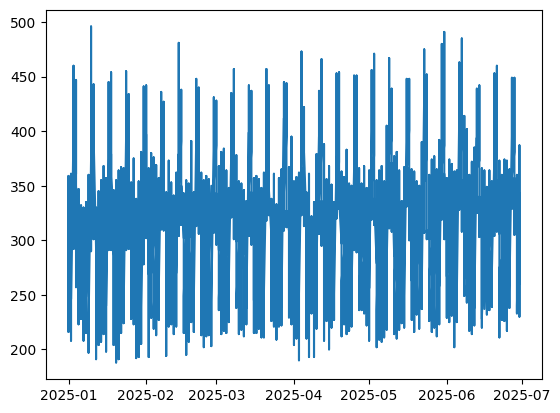

In [15]:
#visualize
import matplotlib.pyplot as plt
plt.plot(daily['date'],daily['demand_qty'])
plt.show()

In [16]:
#moving average forecast
daily['forecast'] = daily['demand_qty'].rolling(7).mean()
daily.head(10)

,date,sku_id,demand_qty,forecast
0,2025-01-01,SKU1,298,NaN
1,2025-01-01,SKU2,281,NaN
2,2025-01-01,SKU3,253,NaN
3,2025-01-01,SKU4,260,NaN
4,2025-01-01,SKU5,227,NaN
5,2025-01-01,SKU6,359,NaN
6,2025-01-01,SKU7,216,270.571429
7,2025-01-01,SKU8,234,261.428571
8,2025-01-02,SKU1,291,262.857143
9,2025-01-02,SKU2,281,266.857143


In [28]:
# Regression based forecast
import numpy as np
from sklearn.linear_model import LinearRegression


daily['day_num'] = np.arange(len(daily))
X = pd.get_dummies(daily[['day_num', 'sku_id']], columns=['sku_id'], drop_first=True)
y = daily['demand_qty']

model = LinearRegression()
model.fit(X, y)

daily['forecast'] = model.predict(X)

daily.head(10)

,date,sku_id,demand_qty,forecast,day_num
0,2025-01-01,SKU1,298,319.082949,0
1,2025-01-01,SKU2,281,320.464164,1
2,2025-01-01,SKU3,253,273.889579,2
3,2025-01-01,SKU4,260,282.535987,3
4,2025-01-01,SKU5,227,249.038750,4
5,2025-01-01,SKU6,359,378.116098,5
6,2025-01-01,SKU7,216,237.044275,6
7,2025-01-01,SKU8,234,271.337092,7
8,2025-01-02,SKU1,291,319.183071,8
9,2025-01-02,SKU2,281,320.564286,9


In [19]:
df['day_of_week'] = df['date'].dt.dayofweek

In [20]:
#Evaluate Wape

wape = abs(daily['demand_qty'] - daily['forecast']).sum() / daily['demand_qty'].sum()
print(wape)

0.16952521003586785


In [39]:
# future forecast
# Determine the last day in your current dataset
last_day_num = daily['day_num'].max()
last_date = daily['date'].max()

# Create a range for the next 180 days (approx 6 months)
future_days = np.arange(last_day_num + 1, last_day_num + 181)
all_skus = daily['sku_id'].unique()

# Create a "Future" dataframe with every SKU for every future day
future_rows = []
for day in future_days:
    for sku in all_skus:
        # Calculate the actual calendar date for reference
        current_date = last_date + pd.Timedelta(days=int(day - last_day_num))
        future_rows.append({'day_num': day, 'sku_id': sku, 'date': current_date})

future_df = pd.DataFrame(future_rows)
future_df

,day_num,sku_id,date
0,1448,SKU1,2025-07-01
1,1448,SKU2,2025-07-01
2,1448,SKU3,2025-07-01
3,1448,SKU4,2025-07-01
4,1448,SKU5,2025-07-01
...,...,...,...
1435,1627,SKU4,2025-12-27
1436,1627,SKU5,2025-12-27
1437,1627,SKU6,2025-12-27
1438,1627,SKU7,2025-12-27


In [37]:
# Prepare Features
# Apply the same encoding used during training
X_future = pd.get_dummies(future_df[['day_num', 'sku_id']], columns=['sku_id'], drop_first=True)

# Important: If any SKUs are missing in the future set that were in the training set,
# you must align the columns so the model doesn't crash.
X_future = X_future.reindex(columns = X.columns, fill_value=0)

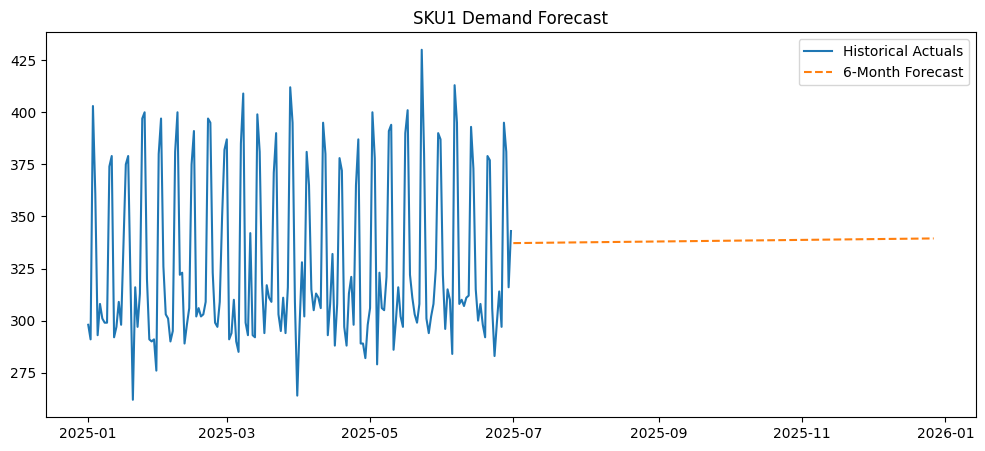

In [38]:
#Predict and Visualize
future_df['forecast'] = model.predict(X_future)

# Plotting SKU1 to see the 6-month trend
import matplotlib.pyplot as plt

sku1_future = future_df[future_df['sku_id'] == 'SKU1']
sku1_hist = daily[daily['sku_id'] == 'SKU1']

plt.figure(figsize=(12, 5))
plt.plot(sku1_hist['date'], sku1_hist['demand_qty'], label='Historical Actuals')
plt.plot(sku1_future['date'], sku1_future['forecast'], label='6-Month Forecast', linestyle='--')
plt.title("SKU1 Demand Forecast")
plt.legend()
plt.show()